# 02 - Data Exploration & Taxonomy Validation

Explores class balance and validates target taxonomies on the ingested catalog:
- **Category Taxonomy (4 classes):** `Academia`, `Fiction`, `Nepali Literature`, `Nonfiction`.
- **Emotion Taxonomy (4 classes):** Validates class signal and support across core emotions.


In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

from app.config import (
    CATALOG_CSV,
    EMBEDDING_MODEL_NAME,
    EMBEDDING_PASSAGE_PREFIX,
    EMBEDDING_QUERY_PREFIX,
    get_logger,
)
from src.ml_from_scratch import NeuralNetwork

logger = get_logger("exploration")

RANDOM_SEED = 42

catalog = pd.read_csv(CATALOG_CSV, dtype={"isbn13": "string"})
logger.info("Loaded catalog: %d rows, %d columns", *catalog.shape)
catalog.head(3)


2026-08-17 18:26:18 | INFO    | booklens.exploration | Loaded catalog: 22568 rows, 11 columns


,isbn13,title,authors,categories,description,published_year,average_rating,num_pages,ratings_count,thumbnail,source
0,9780002005883,Gilead,Marilynne Robinson,Fiction,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,http://books.google.com/books/content?id=KQZCP...,7k_books
1,9780002261982,Spider's Web,Charles Osborne;Agatha Christie,Detective and mystery stories,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,http://books.google.com/books/content?id=gA5GP...,7k_books
2,9780006163831,The One Tree,Stephen R. Donaldson,American fiction,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,http://books.google.com/books/content?id=OmQaw...,7k_books


## 1. Per-Source Composition

Inspects row counts and representation across source datasets.


2026-08-17 18:26:18 | INFO    | booklens.exploration | Rows per source after de-duplication:
source
google_books          13597
7k_books               6568
nepali_books_clean     2403


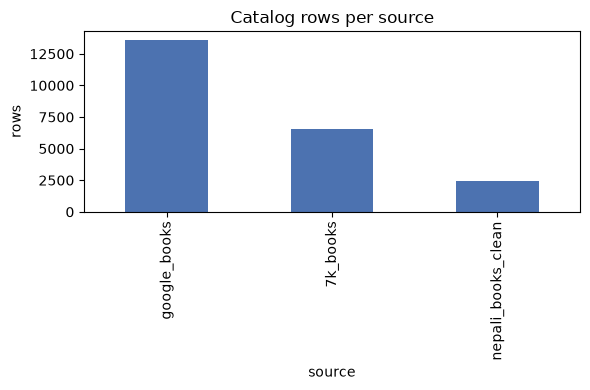

In [2]:
source_counts = catalog["source"].value_counts()
logger.info("Rows per source after de-duplication:\n%s", source_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
source_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("rows")
ax.set_title("Catalog rows per source")
plt.tight_layout()
plt.show()


## 2. Category Taxonomy: Proxy Labels

Maps raw category strings to the 4 candidate classes to check initial class balance.


2026-08-17 18:26:18 | INFO    | booklens.exploration | Proxy category distribution (rough, EDA-only):
_proxy_category
Nonfiction           10022
Fiction               5491
Academia              4652
Nepali Literature     2403


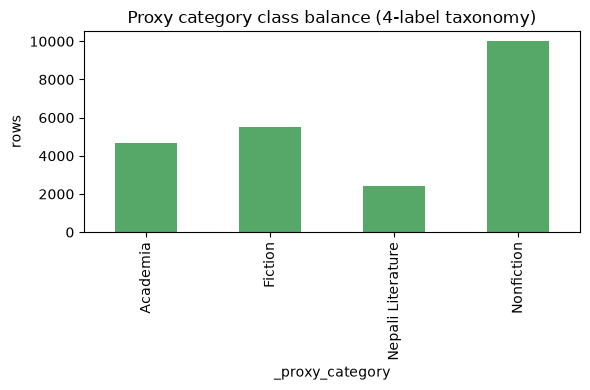

In [3]:
def map_raw_category(raw_category, source) -> str:
    """
    Rough proxy mapping from a raw `categories` string (plus its source) to
    one of the 4 candidate labels. Order matters: checked most-specific
    first (Nepali source, then explicit "nonfiction") down to a Nonfiction
    default, since Nonfiction is the catch-all of the 4 labels.
    """
    if source == "nepali_books_clean":
        return "Nepali Literature"

    text = "" if pd.isna(raw_category) else str(raw_category).lower()

    if "nonfiction" in text:
        return "Nonfiction"

    fiction_markers = (
        "fiction", "stories", "novel", "drama", "poetry", "literary",
        "fantasy", "romance", "mystery", "comics", "graphic novels",
        "adventure", "humor",
    )
    if any(marker in text for marker in fiction_markers):
        return "Fiction"

    academia_markers = (
        "science", "mathematics", "medicine", "medical", "law", "engineering",
        "computers", "technology", "education", "psychology", "philosophy",
        "political science", "business & economics", "social science",
        "encyclopedias", "language arts", "bibliography", "universities",
        "agriculture", "architecture", "reference",
    )
    if any(marker in text for marker in academia_markers):
        return "Academia"

    return "Nonfiction"


catalog["_proxy_category"] = [
    map_raw_category(raw, src) for raw, src in zip(catalog["categories"], catalog["source"])
]

proxy_counts = catalog["_proxy_category"].value_counts()
logger.info("Proxy category distribution (rough, EDA-only):\n%s", proxy_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
proxy_counts.reindex(["Academia", "Fiction", "Nepali Literature", "Nonfiction"]).plot(
    kind="bar", ax=ax, color="#55A868"
)
ax.set_ylabel("rows")
ax.set_title("Proxy category class balance (4-label taxonomy)")
plt.tight_layout()
plt.show()


2026-08-17 18:26:18 | INFO    | booklens.exploration | Per-source composition of each proxy category:
source             7k_books  google_books  nepali_books_clean
_proxy_category                                              
Academia                613          4039                   0
Fiction                3881          1610                   0
Nepali Literature         0             0                2403
Nonfiction             2074          7948                   0


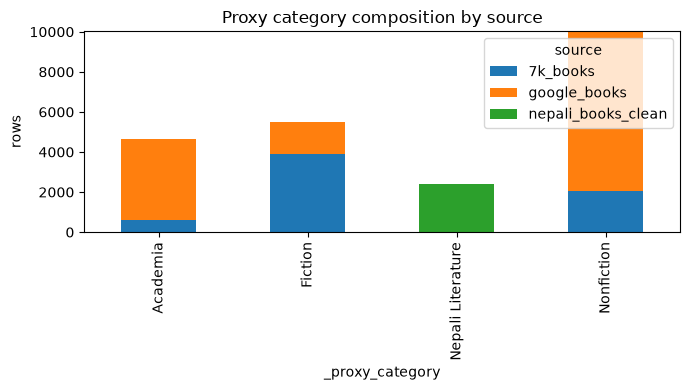

In [4]:
composition = pd.crosstab(catalog["_proxy_category"], catalog["source"])
logger.info("Per-source composition of each proxy category:\n%s", composition.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
composition.loc[["Academia", "Fiction", "Nepali Literature", "Nonfiction"]].plot(
    kind="bar", stacked=True, ax=ax
)
ax.set_ylabel("rows")
ax.set_title("Proxy category composition by source")
ax.legend(title="source")
plt.tight_layout()
plt.show()


## 3. Taxonomy Comparison: Classifier Evaluation

Evaluates candidate category groupings on an 80/20 stratified split using text embeddings and a baseline neural network.


In [5]:
SAMPLE_PER_CLASS = 900

def stratified_sample(df, label_col, n_per_class, seed=RANDOM_SEED):
    parts = [
        group.sample(n=min(n_per_class, len(group)), random_state=seed)
        for _, group in df.groupby(label_col)
    ]
    return pd.concat(parts, ignore_index=True)


eda_sample = stratified_sample(catalog, "_proxy_category", SAMPLE_PER_CLASS)
eda_sample["_search_text"] = (
    eda_sample["title"].fillna("") + " . "
    + eda_sample["categories"].fillna("") + " . "
    + eda_sample["description"].fillna("")
)
logger.info(
    "EDA sample: %d rows across %d proxy-category classes",
    len(eda_sample), eda_sample["_proxy_category"].nunique(),
)


2026-08-17 18:26:19 | INFO    | booklens.exploration | EDA sample: 3600 rows across 4 proxy-category classes


In [6]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)


def embed_passages(texts, batch_size=64):
    """Embed a list of catalog-side texts with the required e5 'passage: ' prefix."""
    prefixed = [EMBEDDING_PASSAGE_PREFIX + text for text in texts]
    return embedding_model.encode(prefixed, normalize_embeddings=True, batch_size=batch_size, show_progress_bar=True)


sample_embeddings = embed_passages(eda_sample["_search_text"].tolist())
logger.info("Embedded EDA sample -> shape %s", sample_embeddings.shape)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

2026-08-17 18:28:26 | INFO    | booklens.exploration | Embedded EDA sample -> shape (3600, 1024)


In [7]:
def fold_academia_into_nonfiction(label: str) -> str:
    return "Nonfiction" if label == "Academia" else label


def audience_split_label(label: str, raw_category) -> str:
    text = "" if pd.isna(raw_category) else str(raw_category).lower()
    is_childrens = any(marker in text for marker in ("juvenile", "young adult", "children"))
    if is_childrens and label in ("Fiction", "Nonfiction"):
        return f"Children's {label}"
    return label


candidate_taxonomies = {
    "4-label": eda_sample["_proxy_category"].tolist(),
    "3-label (Academia folded into Nonfiction)": [
        fold_academia_into_nonfiction(label) for label in eda_sample["_proxy_category"]
    ],
    "Audience-split (+Children's Fiction/Nonfiction)": [
        audience_split_label(label, raw)
        for label, raw in zip(eda_sample["_proxy_category"], eda_sample["categories"])
    ],
}


In [8]:
def evaluate_taxonomy(labels, embeddings, seed=RANDOM_SEED):
    """Train one from-scratch NeuralNetwork on `labels` and report held-out accuracy + macro-F1."""
    label_names = sorted(set(labels))
    label_to_idx = {name: i for i, name in enumerate(label_names)}
    y = np.array([label_to_idx[label] for label in labels])

    X_train, X_val, y_train, y_val = train_test_split(
        embeddings, y, test_size=0.2, random_state=seed, stratify=y
    )

    model = NeuralNetwork(input_dim=X_train.shape[1], hidden_dim=64, output_dim=len(label_names), seed=seed)
    model.fit(
        X_train, y_train, X_val, y_val,
        epochs=60, batch_size=32, learning_rate=0.1,
        class_weight="balanced", logger=None,
    )

    val_predictions = model.predict(X_val)
    return {
        "n_labels": len(label_names),
        "accuracy": accuracy_score(y_val, val_predictions),
        "macro_f1": f1_score(y_val, val_predictions, average="macro"),
    }


taxonomy_results = {}
for name, labels in candidate_taxonomies.items():
    result = evaluate_taxonomy(labels, sample_embeddings)
    taxonomy_results[name] = result
    logger.info(
        "%s: %d labels, accuracy=%.3f, macro_f1=%.3f",
        name, result["n_labels"], result["accuracy"], result["macro_f1"],
    )

taxonomy_results_df = pd.DataFrame(taxonomy_results).T
taxonomy_results_df


2026-08-17 18:28:27 | INFO    | booklens.exploration | 4-label: 4 labels, accuracy=0.886, macro_f1=0.884
2026-08-17 18:28:27 | INFO    | booklens.exploration | 3-label (Academia folded into Nonfiction): 3 labels, accuracy=0.968, macro_f1=0.968
2026-08-17 18:28:28 | INFO    | booklens.exploration | Audience-split (+Children's Fiction/Nonfiction): 6 labels, accuracy=0.882, macro_f1=0.837


,n_labels,accuracy,macro_f1
4-label,4.0,0.886111,0.884265
3-label (Academia folded into Nonfiction),3.0,0.968056,0.968440
Audience-split (+Children's Fiction/Nonfiction),6.0,0.881944,0.836865


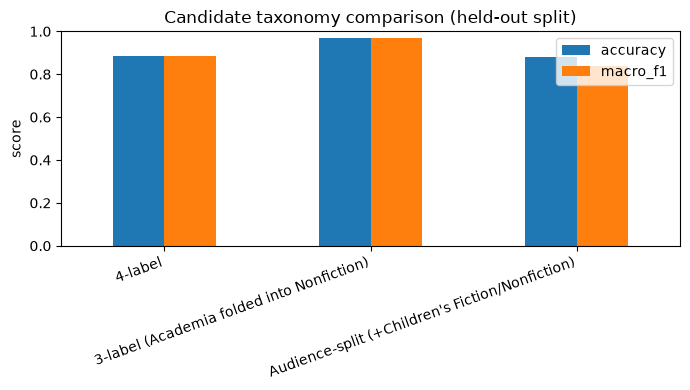

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
taxonomy_results_df[["accuracy", "macro_f1"]].plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title("Candidate taxonomy comparison (held-out split)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 4. Emotion Taxonomy Support

Evaluates emotion label support with `j-hartmann/emotion-english-distilroberta-base` to identify high-signal emotion classes.


In [10]:
import torch
from transformers import pipeline

from app.config import EMOTION_MODEL_NAME

_device = "mps" if torch.backends.mps.is_available() else (0 if torch.cuda.is_available() else -1)
emotion_classifier = pipeline("text-classification", model=EMOTION_MODEL_NAME, top_k=None, device=_device)

sample_texts = (
    eda_sample["title"].fillna("") + ". " + eda_sample["description"].fillna("")
).str[:400].tolist()

logger.info("Running the emotion classifier on %d EDA samples...", len(sample_texts))
raw_scores = emotion_classifier(sample_texts, batch_size=32, truncation=True)
top_labels = [max(scores, key=lambda s: s["score"])["label"] for scores in raw_scores]

emotion_support = pd.Series(top_labels).value_counts()
logger.info("Emotion classifier support on the EDA sample (native 7 labels):\n%s", emotion_support.to_string())


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

2026-08-17 18:28:33 | INFO    | booklens.exploration | Running the emotion classifier on 3600 EDA samples...
2026-08-17 18:28:47 | INFO    | booklens.exploration | Emotion classifier support on the EDA sample (native 7 labels):
neutral     2023
joy          659
fear         476
disgust      191
sadness      124
anger         86
surprise      41


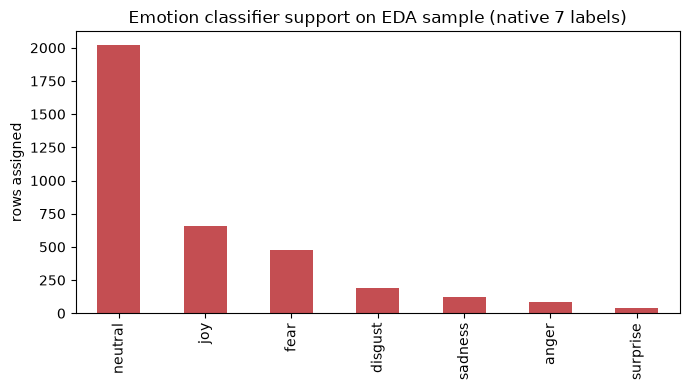

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
emotion_support.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("rows assigned")
ax.set_title("Emotion classifier support on EDA sample (native 7 labels)")
plt.tight_layout()
plt.show()
